In [1]:
# https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f

import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
import torchvision.utils as vutils

from torchvision.datasets import ImageFolder
from torchvision.utils import save_image, make_grid

In [2]:
dataroot = "../data"

workers = 2
batch_size = 100
image_size = 64
input_dim = image_size * image_size * 3  # Assuming RGB images

dataset = ImageFolder(root=dataroot,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                           ]))
# Create the dataloader
train_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


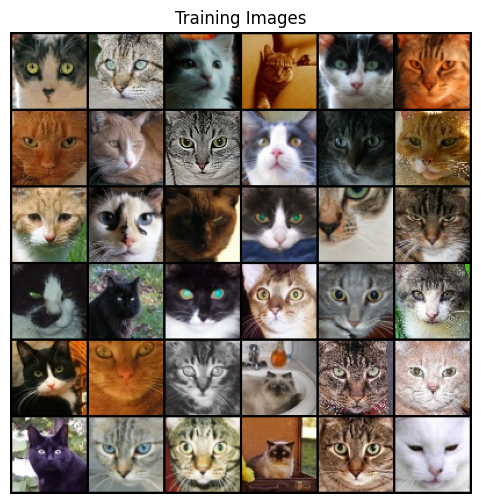

In [3]:
real_batch = next(iter(train_loader))
plt.figure(figsize=(6,6))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:36], nrow=6, padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [4]:
class Encoder(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=256):
        super(Encoder, self).__init__()

        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.var = nn.Linear (hidden_dim, latent_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)
        self.training = True

    def forward(self, x):
        x = self.LeakyReLU(self.linear1(x))
        x = self.LeakyReLU(self.linear2(x))

        mean = self.mean(x)
        log_var = self.var(x)
        return mean, log_var

In [5]:
class Decoder(nn.Module):

    def __init__(self, output_dim=784, hidden_dim=512, latent_dim=256):
        super(Decoder, self).__init__()

        self.linear2 = nn.Linear(latent_dim, hidden_dim)
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.LeakyReLU(self.linear2(x))
        x = self.LeakyReLU(self.linear1(x))

        x_hat = torch.sigmoid(self.output(x))
        return x_hat

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim=input_dim, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim),
            nn.LeakyReLU(0.2)
        )

        # latent mean and variance
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, latent_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)
        z = mean + var * epsilon
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, torch.exp(0.5 * logvar))
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [7]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [8]:
def train(model, optimizer, epochs, device):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(x.size(0), -1).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)

            try:
                loss = loss_function(x, x_hat, mean, log_var)
            except:
                print("x_hat min:", x_hat.min().item(), "max:", x_hat.max().item())

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss / (batch_idx * batch_size))
    return overall_loss

In [9]:
train(model, optimizer, epochs=20, device=device)

	Epoch 1 	Average Loss:  7938.483136535235
	Epoch 2 	Average Loss:  7635.264878355705
	Epoch 3 	Average Loss:  7615.166192323825
	Epoch 4 	Average Loss:  7600.305090184564
	Epoch 5 	Average Loss:  7588.022554530201
	Epoch 6 	Average Loss:  7578.203216233222
	Epoch 7 	Average Loss:  7573.2452674077185
	Epoch 8 	Average Loss:  7568.331445050336
	Epoch 9 	Average Loss:  7564.2414649748325
	Epoch 10 	Average Loss:  7564.42646602349
	Epoch 11 	Average Loss:  7559.395025167785
	Epoch 12 	Average Loss:  7557.503778313759
	Epoch 13 	Average Loss:  7555.788196308725
	Epoch 14 	Average Loss:  7556.836376887584
	Epoch 15 	Average Loss:  7551.349512374161
	Epoch 16 	Average Loss:  7551.033246644295
	Epoch 17 	Average Loss:  7556.042084731544
	Epoch 18 	Average Loss:  7551.866945260067
	Epoch 19 	Average Loss:  7547.591059144295
	Epoch 20 	Average Loss:  7544.863373531879


224836928.53125

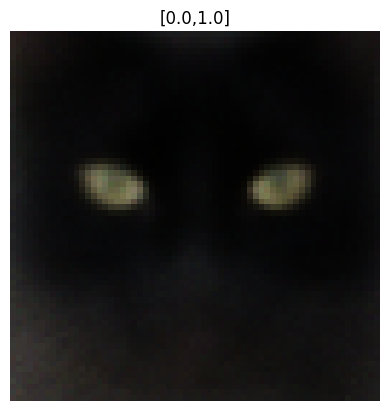

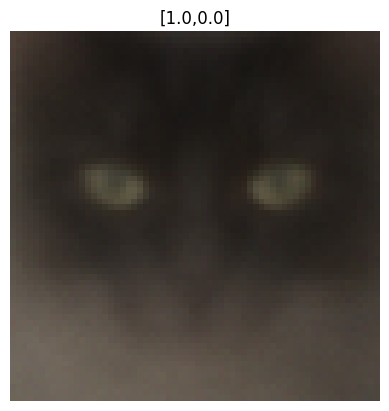

(None, None)

In [12]:
def generate_cat(mean, var):
    z_sample = torch.tensor([[mean, var]], dtype=torch.float).to(device)
    x_decoded = model.decode(z_sample)
    cat = x_decoded[0].detach().cpu().numpy()
    cat = cat.reshape(3, 64, 64)  # Reshape to (channels, height, width)
    cat = np.transpose(cat, (1, 2, 0))
    # cat = (cat - cat.min()) / (cat.max() - cat.min())
    plt.title(f'[{mean},{var}]')
    plt.imshow(cat)
    plt.axis('off')
    plt.show()

generate_cat(0.0, 1.0), generate_cat(1.0, 0.0)

/tmp/ipykernel_3068517/1476398116.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  figure[i * cat_size : (i + 1) * cat_size, j * cat_size : (j + 1) * cat_size,] = cat


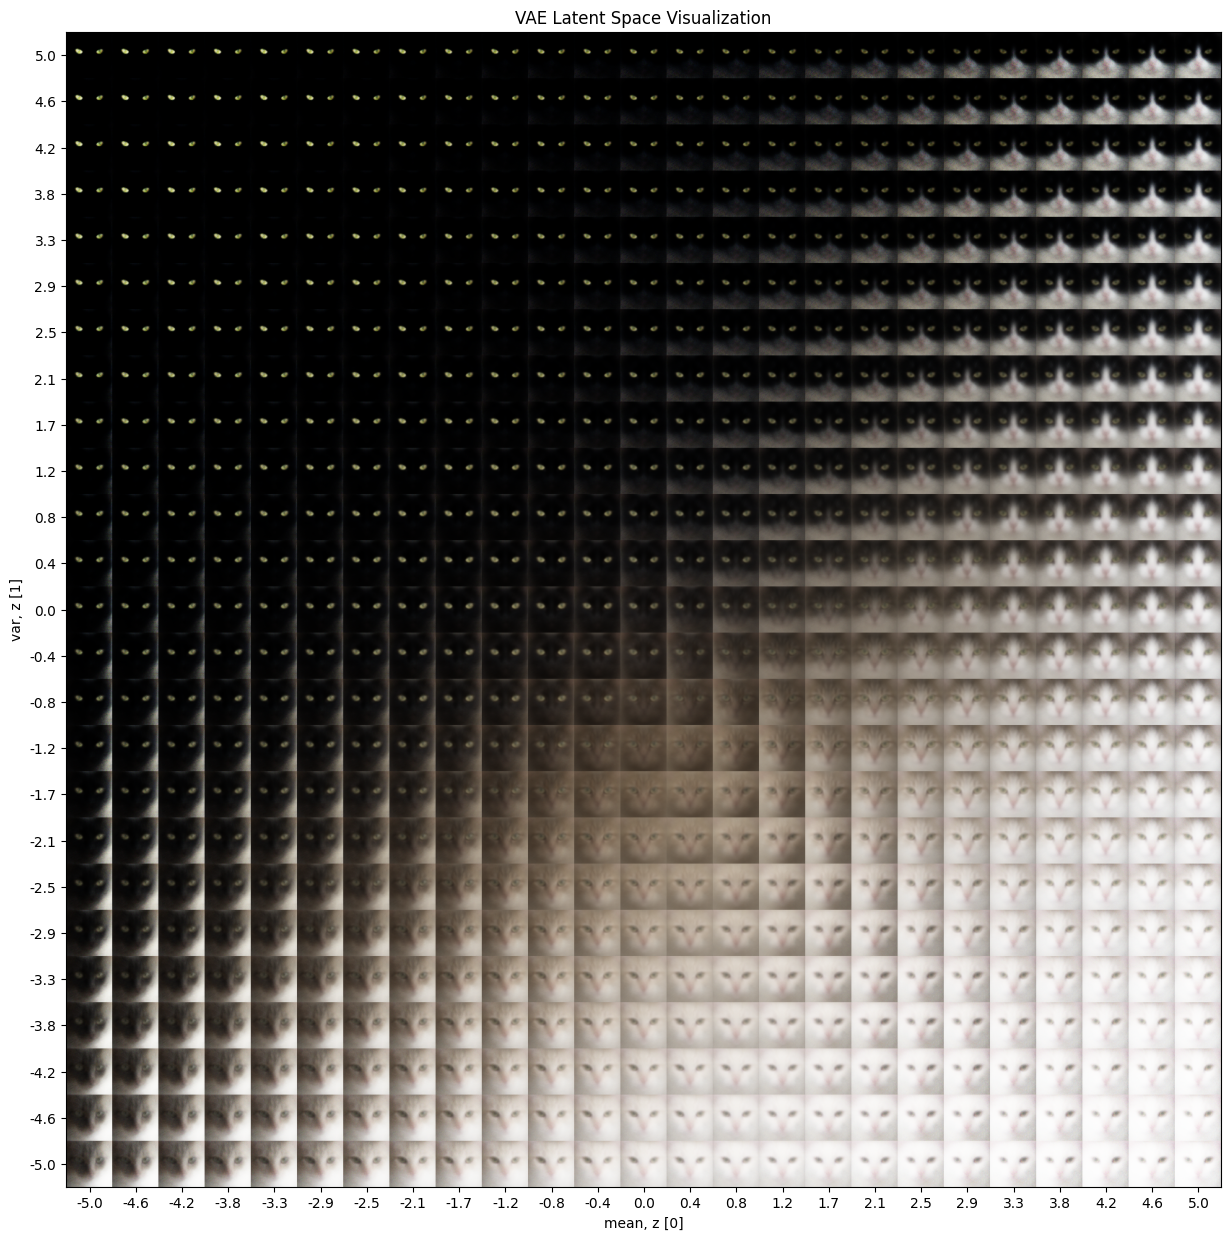

In [13]:
def plot_latent_space(model, scale=5.0, n=25, cat_size=64, figsize=15):
    figure = np.zeros((cat_size * n, cat_size * n, 3))

    # construct a grid
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            # Reshape to 64x64x3
            cat = x_decoded[0].detach().cpu().reshape(3, cat_size, cat_size)
            cat = np.transpose(cat, (1, 2, 0))
            figure[i * cat_size : (i + 1) * cat_size, j * cat_size : (j + 1) * cat_size,] = cat

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = cat_size // 2
    end_range = n * cat_size + start_range
    pixel_range = np.arange(start_range, end_range, cat_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure)
    plt.show()

plot_latent_space(model)